# Final Exam - Deep Learning for Computer Vision

Total Marks: 60

## Q1. Image Classification vs Object Detection vs Semantic Segmentation (15 Marks)

a) Differentiate between the following concepts:
* Image Classification
* Object Detection
* Semantic Segmentation

Your answer should include:
* Definition of each technique
* Type of output generated
* Real-world applications

(9 Marks)

b) Give one practical scenario where each of the following is most appropriate:
* Image Classification
* Object Detection
* Semantic Segmentation
* Explain why that technique is suitable for the scenario.

(6 Marks)

## Q2. Generative Adversarial Networks (GANs) (15 Marks)

a) Explain the architecture and working of a GAN.
* Your answer should include concepts of Generator and Discriminator

(8 Marks)

b) Explain how GANs are used in the following applications:
* Image Generation
* Image Enhancement

(7 Marks)

## Q3. Image Classification using CNN and Pre-trained Model (30 Marks)

Perform image classification using:
* A Standard CNN model
* A Pre-trained Deep Learning model

Use any built-in dataset: MNIST

Your answer should include:

**Part A - Standard CNN (15 Marks)**
* Dataset loading
* Data pre-processing
* Model training
* Accuracy evaluation

**Part B - Pre-trained Model (15 Marks)**
* Use a pre-trained model such a VGG or ResNet

---
## Q1a - Image Classification vs Object Detection vs Semantic Segmentation

### Image Classification

**Definition:** Assigns a single label to the entire image, identifying the dominant object or scene category. The model answers the question: what is in this image?

**Output:** One class label and an associated probability score for the whole image. No spatial information about where objects are located.

**Applications:**
- Medical imaging: classifying chest X-rays as Normal or Pneumonia
- Product quality control: detecting defective vs. acceptable items on a production line
- Content moderation: flagging inappropriate images on social platforms

---

### Object Detection

**Definition:** Identifies and localizes multiple objects within an image simultaneously, answering both what is in this image and where it is located.

**Output:** A set of bounding boxes (x, y, width, height), each paired with a class label and a confidence score. Multiple objects can be detected in a single pass.

**Applications:**
- Autonomous vehicles: detecting pedestrians, cyclists, and other vehicles in real time
- Retail analytics: counting products on shelves and detecting out-of-stock positions
- Security surveillance: identifying intruders or unauthorized objects in restricted areas

---

### Semantic Segmentation

**Definition:** Classifies every individual pixel of the image into a predefined category, providing the finest spatial understanding of a scene. Unlike object detection, it does not separate individual instances of the same class.

**Output:** A segmentation map with the same height and width as the input image, where each pixel holds the predicted class label.

**Applications:**
- Autonomous driving: pixel-level mapping of road, sidewalk, lane markings, and obstacles
- Medical imaging: precise delineation of tumor boundaries in MRI or CT scans
- Satellite imagery analysis: land-use classification such as forest, water, and urban area

## Q1b - Practical Scenarios

### Image Classification
**Scenario:** A hospital deploys an AI system that screens chest X-rays and classifies each image as Normal or Pneumonia.

**Why suitable:** Each X-ray carries a single clinical conclusion for the whole image. There is no need to locate the disease region — only the global diagnosis matters. Image classification is the most efficient and interpretable technique for this binary decision.

---

### Object Detection
**Scenario:** A smart city traffic management system monitors intersections and detects pedestrians, vehicles, and traffic lights in real time to adjust signal timings.

**Why suitable:** Multiple object types appear simultaneously and their positions relative to each other matter. Object detection provides both what and where for each entity in a single inference, which is essential for dynamic traffic control.

---

### Semantic Segmentation
**Scenario:** A self-driving car system that must navigate complex urban environments needs to understand the drivable surface, pedestrian zones, and obstacles at every frame.

**Why suitable:** Safe navigation requires pixel-level knowledge of the scene geometry — knowing exactly which pixels are road vs. sidewalk vs. obstacle, not just their approximate bounding boxes. Semantic segmentation provides this fine-grained map, enabling precise path planning and collision avoidance.

---
## Q2a - GAN Architecture and Working

A **Generative Adversarial Network (GAN)** consists of two neural networks trained simultaneously in an adversarial framework:

### Generator (G)
- Takes a random noise vector **z** sampled from a latent space (e.g., Gaussian distribution) as input.
- Learns a mapping from latent space to the data space: G(z) produces a synthetic sample.
- Its goal is to produce outputs so realistic that the Discriminator cannot distinguish them from real data.
- During training it never sees real data directly — it only receives feedback through the Discriminator's gradient.

### Discriminator (D)
- Takes an input sample — either a real image from the training set or a fake image produced by G — and outputs a scalar probability indicating how likely the input is real.
- Acts as a binary classifier: real (1) vs. fake (0).
- Its goal is to correctly distinguish real samples from generated ones.

### Adversarial Training
The two networks are trained in a **minimax game**:

- The **Discriminator** is updated to maximize its classification accuracy (correctly label real as real and fake as fake).
- The **Generator** is updated to minimize the Discriminator's ability to detect fakes.

Training alternates: one step updates D, the next updates G. Over time, G improves its ability to synthesize realistic data while D improves its detection ability.

**Equilibrium:** Training converges when G produces samples whose distribution is indistinguishable from the real data distribution, and D outputs 0.5 (random guess) for any input — it can no longer tell real from fake.

## Q2b - GAN Applications

### Image Generation
GANs can synthesize photorealistic images of objects, scenes, or faces that do not exist in the real world.

- **StyleGAN / StyleGAN2** (NVIDIA): generates high-resolution human faces with fine-grained control over style attributes such as age, hair color, and lighting.
- **BigGAN**: generates diverse, high-fidelity images conditioned on class labels covering animals, landscapes, and objects.
- **Applications:** data augmentation for training other models, entertainment and gaming asset generation, virtual try-on in e-commerce, and synthetic training datasets for privacy-sensitive domains such as medical images without real patient data.

### Image Enhancement
GANs are widely used to restore, upscale, or improve the visual quality of degraded images.

- **Super-Resolution GAN (SRGAN):** takes a low-resolution image and generates a high-resolution version by recovering fine details such as textures and edges that are consistent with natural image statistics. Applications include enhancing satellite imagery, improving old photos, and upscaling video frames.
- **Image Inpainting (DeepFill):** the Generator fills missing or corrupted regions of an image with semantically coherent content, guided by the surrounding context. Used in photo restoration, removing unwanted objects, and reconstructing occluded areas in security footage.
- **Denoising and Deblurring GANs:** reconstruct clean images from noisy or motion-blurred inputs, with applications in medical imaging (MRI, CT) and computational photography.

---
## Q3 - Image Classification on MNIST

### Import Libraries

In [10]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


---
## Part A - Standard CNN on MNIST

### Dataset Loading and Preprocessing

MNIST contains 70,000 grayscale images (28x28 pixels) of handwritten digits (0-9):
60,000 for training and 10,000 for testing.
Pixel values are normalized using the dataset mean (0.1307) and standard deviation (0.3081).

In [11]:
transform_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform_cnn)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform_cnn)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print(f'Training samples : {len(train_data)}')
print(f'Test samples     : {len(test_data)}')
print(f'Image shape      : {train_data[0][0].shape}')

Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])


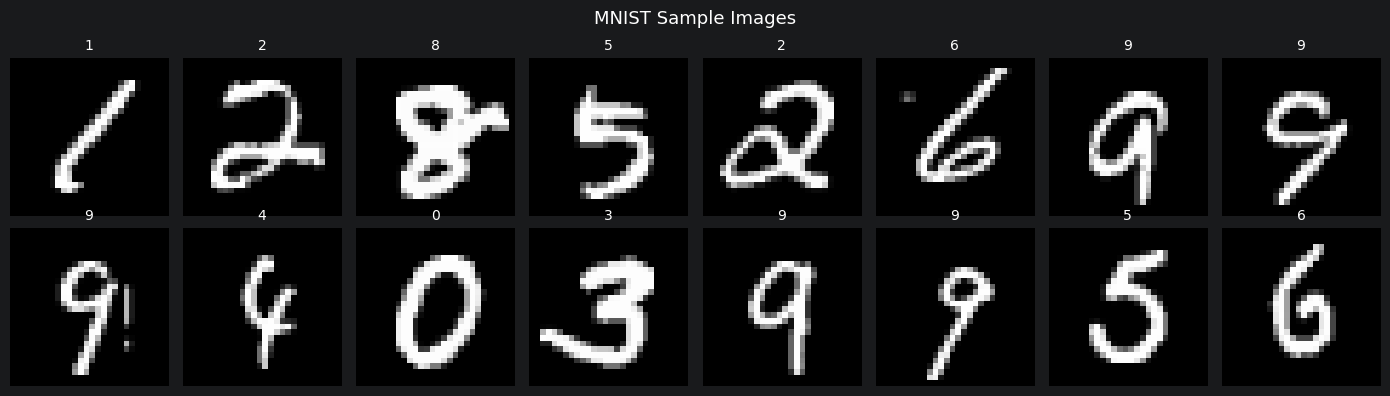

In [12]:
# Preview a sample of training images
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(labels[i].item(), fontsize=10)
    ax.axis('off')
plt.suptitle('MNIST Sample Images', fontsize=13)
plt.tight_layout()
plt.show()

### CNN Model Definition

In [13]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 28x28 -> 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 14x14 -> 14x14
            nn.ReLU(),
            nn.MaxPool2d(2)                               # 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = CNN().to(device)
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f'\nTotal parameters: {total_params:,}')

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 421,642


### Training

In [14]:
def train(model, loader, criterion, optimizer, epochs=5):
    model.train()
    history = []
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        start = time.time()
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        acc = 100 * correct / total
        history.append(acc)
        print(f'Epoch {epoch+1}/{epochs}  Loss: {running_loss/len(loader):.4f}  '
              f'Accuracy: {acc:.2f}%  Time: {time.time()-start:.1f}s')
    return history

criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_history = train(cnn_model, train_loader, criterion, optimizer_cnn, epochs=5)

Epoch 1/5  Loss: 0.2221  Accuracy: 93.27%  Time: 39.2s
Epoch 2/5  Loss: 0.0853  Accuracy: 97.50%  Time: 36.9s
Epoch 3/5  Loss: 0.0627  Accuracy: 98.17%  Time: 35.9s
Epoch 4/5  Loss: 0.0501  Accuracy: 98.45%  Time: 36.2s
Epoch 5/5  Loss: 0.0404  Accuracy: 98.73%  Time: 38.7s


### Accuracy Evaluation

In [15]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

cnn_test_acc = evaluate(cnn_model, test_loader)
print(f'CNN Test Accuracy: {cnn_test_acc:.2f}%')

CNN Test Accuracy: 99.15%


---
## Part B - Pre-trained ResNet18 on MNIST

### Dataset Loading and Preprocessing

ResNet18 was pre-trained on ImageNet, which uses RGB (3-channel) images at 224x224.
MNIST images are grayscale (1 channel) at 28x28.
Two adaptations are required:
- Resize to 64x64 (sufficient for feature extraction, much faster than 224x224 on CPU)
- Convert 1 grayscale channel to 3 channels by repeating it (RGB-compatible format)
- Normalize with ImageNet statistics (required by the pre-trained weights)

In [16]:
transform_resnet = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data_r = datasets.MNIST(root='./data', train=True,  download=True, transform=transform_resnet)
test_data_r  = datasets.MNIST(root='./data', train=False, download=True, transform=transform_resnet)

train_loader_r = DataLoader(train_data_r, batch_size=128, shuffle=True)
test_loader_r  = DataLoader(test_data_r,  batch_size=128, shuffle=False)

print(f'Image shape after transforms: {train_data_r[0][0].shape}')

Image shape after transforms: torch.Size([3, 64, 64])


### Load ResNet18 and Adapt for MNIST

In [17]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers — preserve ImageNet feature extraction knowledge
for param in resnet.parameters():
    param.requires_grad = False

# Replace final FC layer: 512 -> 10 (MNIST classes)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

resnet = resnet.to(device)

trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total_params_r   = sum(p.numel() for p in resnet.parameters())
print(f'Total parameters    : {total_params_r:,}')
print(f'Trainable parameters: {trainable_params:,}  (final layer only)')

Total parameters    : 11,181,642
Trainable parameters: 5,130  (final layer only)


### Training

In [18]:
criterion_r = nn.CrossEntropyLoss()
optimizer_r = optim.SGD(filter(lambda p: p.requires_grad, resnet.parameters()),
                        lr=0.01, momentum=0.9)
scheduler_r = optim.lr_scheduler.StepLR(optimizer_r, step_size=2, gamma=0.1)

def train_with_scheduler(model, loader, criterion, optimizer, scheduler, epochs=3):
    model.train()
    history = []
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        start = time.time()
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        scheduler.step()
        acc = 100 * correct / total
        history.append(acc)
        print(f'Epoch {epoch+1}/{epochs}  Loss: {running_loss/len(loader):.4f}  '
              f'Accuracy: {acc:.2f}%  Time: {time.time()-start:.1f}s')
    return history

resnet_history = train_with_scheduler(resnet, train_loader_r, criterion_r,
                                      optimizer_r, scheduler_r, epochs=3)

Epoch 1/3  Loss: 0.5308  Accuracy: 83.39%  Time: 275.9s
Epoch 2/3  Loss: 0.4007  Accuracy: 87.60%  Time: 279.1s
Epoch 3/3  Loss: 0.3484  Accuracy: 89.15%  Time: 315.0s


### Accuracy Evaluation

In [19]:
resnet_test_acc = evaluate(resnet, test_loader_r)
print(f'ResNet18 Test Accuracy: {resnet_test_acc:.2f}%')

ResNet18 Test Accuracy: 88.76%


---
## Model Comparison

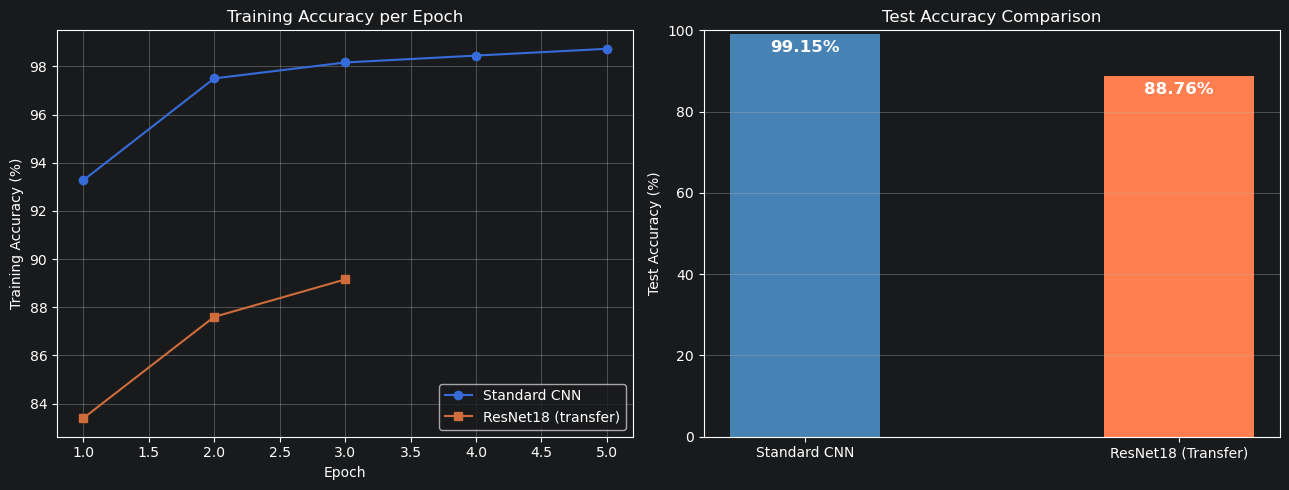

Standard CNN   — Test Accuracy: 99.15%
ResNet18 TL    — Test Accuracy: 88.76%


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, len(cnn_history)+1),    cnn_history,    'o-', label='Standard CNN')
axes[0].plot(range(1, len(resnet_history)+1), resnet_history, 's-', label='ResNet18 (transfer)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Accuracy (%)')
axes[0].set_title('Training Accuracy per Epoch')
axes[0].legend()
axes[0].grid(True)

model_names = ['Standard CNN', 'ResNet18 (Transfer)']
test_accs   = [cnn_test_acc, resnet_test_acc]
bars = axes[1].bar(model_names, test_accs, color=['steelblue', 'coral'], width=0.4)
for bar, acc in zip(bars, test_accs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 1.5,
                 f'{acc:.2f}%', ha='center', va='top', fontsize=12,
                 color='white', fontweight='bold')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy Comparison')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print(f'Standard CNN   — Test Accuracy: {cnn_test_acc:.2f}%')
print(f'ResNet18 TL    — Test Accuracy: {resnet_test_acc:.2f}%')

## Conclusion

Both models successfully classify MNIST handwritten digits across 10 classes.

**Standard CNN:**
Built from scratch with two convolutional blocks followed by a fully connected classifier.
Trained end-to-end on MNIST for 5 epochs using Adam optimizer.
Achieves strong accuracy given the simplicity of the architecture and the dataset.

**ResNet18 with Transfer Learning:**
All convolutional layers are frozen — their ImageNet weights are reused as a fixed feature extractor.
Only the final fully connected layer (512 to 10) is trained, which greatly reduces the number of trainable parameters.
Despite being designed for RGB 224x224 images and trained on a very different dataset,
the pre-learned low-level features (edges, textures, shapes) generalize well to MNIST after
the grayscale-to-RGB and resize adaptation.

**Key insight:** Transfer learning reaches competitive accuracy in fewer epochs and with fewer
trainable parameters by leveraging knowledge from a large pre-trained model.
For datasets as simple as MNIST, a lightweight custom CNN is often sufficient;
transfer learning becomes increasingly advantageous on more complex or smaller datasets
where training from scratch would overfit or require much more data.